## Introduction and research question

Following Darwin’s publication of his groundbreaking theory of evolution in his “On the Origins of Species”, the concept of evolution quickly inspired novel approaches in disciplines well beyond biology. Social scientists, too, started investigating how cultures evolved over time. The study of music which, like language, is a universal feature found in varying forms across all human cultures, drew on such ideas, conducting large-scale analyses of music across cultures to understand how human cultures evolved (Savage 2019). Beyond these largely academic concerns, the question of how music evolves has recently gained significance as actors in the entertainment industry try to understand and predict ever-changing musical trends (see Terroso-Saenz et al. 2019). As a result, we ask: How has Western music evolved over the last 100 years?


Answering these questions has long been hamstrung by the difficulty of obtaining large-enough samples and strict metrics that could move discussions on musical evolution beyond the arcane realm of musical afficionados into concrete and data-based research. Yet this has changed with the advent of larger digital dataset (e.g., from Spotify) and more sophisticated methods of computational analysis (Youngblood et al. 2019). For example, Mauch and colleagues (2015) deconstruct chart-topping songs into auditive ‘tokens’ based on the songs’ tonal content and timbre before applying latent Dirichlet allocation (LDA) to identify song genres and track what features and genres were most popular over time. We complement such works through the use of an alternative dataset and machine learning approach, both of which are consequently described.


**Bibliography**

Mauch, Matthias, Robert M. MacCallum, Mark Levy, and Armand M. Leroi. 2015. “The Evolution of Popular Music: USA 1960–2010.” Royal Society Open Science 2 (5): 150081. https://doi.org/10.1098/rsos.150081.

Savage, Patrick E. 2019. “Cultural Evolution of Music.” Palgrave Communications 5 (1): 16. https://doi.org/10.1057/s41599-019-0221-1.

Terroso-Saenz, Fernando, Jesus Soto, and Andres Muñoz. 2023. “Evolution of Global Music Trends: An Exploratory and Predictive Approach Based on Spotify Data.” Entertainment Computing 44 (January). https://doi.org/10.1016/j.entcom.2022.100536.

Youngblood, Mason, Yuto Ozaki, and Patrick E. Savage. 2023. “Cultural Evolution and Music.” In The Oxford Handbook of Cultural Evolution, edited by Jamshid J. Tehrani, Jeremy Kendal, and Rachel Kendal, [online]. Oxford University Press. https://doi.org/10.1093/oxfordhb/9780198869252.013.42.



## Data Cleaning, Exploration, and Feature Engineering

Importing all the necessary libraries and loading the dataset

In [1]:
import csv
import pandas as pd
import numpy as np

tracks = pd.read_csv("tracks.csv")
tracks.head(n = 10)

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.744000,0.1510,0.1270,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.000000,0.1480,0.6550,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.021800,0.2120,0.4570,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.918000,0.1040,0.3970,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.130000,0.3110,0.1960,103.220,4
5,0BRXJHRNGQ3W4v9frnSfhu,Ave Maria,0,178933,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.227,0.2610,5,-12.343,1,0.0382,0.994,0.247000,0.0977,0.0539,118.891,4
6,0Dd9ImXtAtGwsmsAD69KZT,La Butte Rouge,0,134467,0,['Francis Marty'],['2nuMRGzeJ5jJEKlfS7rZ0W'],1922,0.510,0.3550,4,-12.833,1,0.1240,0.965,0.000000,0.1550,0.7270,85.754,5
7,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,['Mistinguett'],['4AxgXfD7ISvJSTObqm4aIE'],1922,0.563,0.1840,4,-13.757,1,0.0512,0.993,0.000016,0.3250,0.6540,133.088,3
8,0IgI1UCz84pYeVetnl1lGP,Old Fashioned Girl,0,310073,0,['Greg Fieler'],['5nWlsH5RDgFuRAiDeOFVmf'],1922,0.488,0.4750,0,-16.222,0,0.0399,0.620,0.006450,0.1070,0.5440,139.952,4
9,0JV4iqw2lSKJaHBQZ0e5zK,Martín Fierro - Remasterizado,0,181173,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-29,0.548,0.0391,6,-23.228,1,0.1530,0.996,0.933000,0.1480,0.6120,75.595,3


Below is a brief overview of the raw data.


In [2]:
tracks.columns

Index(['id', 'name', 'popularity', 'duration_ms', 'explicit', 'artists',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature'],
      dtype='object')

In [3]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  object 
 1   name              586601 non-null  object 
 2   popularity        586672 non-null  int64  
 3   duration_ms       586672 non-null  int64  
 4   explicit          586672 non-null  int64  
 5   artists           586672 non-null  object 
 6   id_artists        586672 non-null  object 
 7   release_date      586672 non-null  object 
 8   danceability      586672 non-null  float64
 9   energy            586672 non-null  float64
 10  key               586672 non-null  int64  
 11  loudness          586672 non-null  float64
 12  mode              586672 non-null  int64  
 13  speechiness       586672 non-null  float64
 14  acousticness      586672 non-null  float64
 15  instrumentalness  586672 non-null  float64
 16  liveness          58

In [4]:
tracks.describe()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,586672.000000,5.866720e+05,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000,586672.000000
mean,27.570053,2.300512e+05,0.044086,0.563594,0.542036,5.221603,-10.206067,0.658797,0.104864,0.449863,0.113451,0.213935,0.552292,118.464857,3.873382
std,18.370642,1.265261e+05,0.205286,0.166103,0.251923,3.519423,5.089328,0.474114,0.179893,0.348837,0.266868,0.184326,0.257671,29.764108,0.473162
min,0.000000,3.344000e+03,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,1.750930e+05,0.000000,0.453000,0.343000,2.000000,-12.891000,0.000000,0.034000,0.096900,0.000000,0.098300,0.346000,95.600000,4.000000
50%,27.000000,2.148930e+05,0.000000,0.577000,0.549000,5.000000,-9.243000,1.000000,0.044300,0.422000,0.000024,0.139000,0.564000,117.384000,4.000000
75%,41.000000,2.638670e+05,0.000000,0.686000,0.748000,8.000000,-6.482000,1.000000,0.076300,0.785000,0.009550,0.278000,0.769000,136.321000,4.000000
max,100.000000,5.621218e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.971000,0.996000,1.000000,1.000000,1.000000,246.381000,5.000000


Checking for missing data

In [5]:
tracks.isna().sum()

id                   0
name                71
popularity           0
duration_ms          0
explicit             0
artists              0
id_artists           0
release_date         0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
time_signature       0
dtype: int64

In [6]:
tracks[tracks["name"].isna()].head(n = 5)

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
226336,4iH7negBYMfj2z0wDNmgdx,NaN,28,264973,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1994-01-01,0.512,0.578,0,-12.280,0,0.0299,0.0433,0.000064,0.516,0.692,156.465,1
510975,04d5kbLvSAIBt3pGcljdhC,NaN,0,184293,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.426,0.285,11,-11.970,1,0.0466,0.9950,0.264000,0.293,0.583,135.661,4
510976,05tRkgyxVdwMePGqOXMDYU,NaN,0,191587,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.344,0.186,0,-13.495,1,0.0745,0.9950,0.000000,0.115,0.290,79.591,1
510978,0YAMRgAQH6tkTh4sWNXr8L,NaN,0,191573,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.316,0.257,3,-13.611,0,0.0549,0.9950,0.769000,0.519,0.529,68.682,3
510979,1K6MQQxmFpPb66ZnaiIpHX,NaN,0,167602,0,[''],['0LyfQWJT6nXafLPZqxe9Of'],1922-04-01,0.558,0.283,1,-12.847,1,0.0646,0.9960,0.000000,0.453,0.608,70.379,4


Although the variable name has missing entries, it does not affect our analysis much as this column will already be removed as we drop unnecessary features from our dataset. Some of the variables that we would not need for our models include "name", "artists", "id_artists", "id", "time_signature", etc. We will also remove the variable "popularity" since our research question has more to do with identifying which musical attributes define a particular musical period and less to do with the popularity of the track itself.

In [7]:
tracks = tracks.drop(["name", "artists", "id_artists", "id", "time_signature", "popularity"], axis = 1)

In [8]:
tracks.head(n = 5)

,duration_ms,explicit,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,126903,0,1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851
1,98200,0,1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009
2,181640,0,1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418
3,176907,0,1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980
4,163080,0,1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220


We need a target variable for our task, which will identify different musical periods and that we are interested in predicting. By doing so, we can extract the top three features or musical attributes that are linked to each musical period. Below is the code that does exactly this.

In [9]:
tracks["release_year"] = tracks["release_date"].str[:4].astype(int)
tracks.drop(["release_date"], axis = 1, inplace = True)

print(any(tracks["release_year"].isna()))
print("\n", tracks.head(5))

False

    duration_ms  explicit  danceability  energy  key  loudness  mode  \
0       126903         0         0.645  0.4450    0   -13.338     1   
1        98200         0         0.695  0.2630    0   -22.136     1   
2       181640         0         0.434  0.1770    1   -21.180     1   
3       176907         0         0.321  0.0946    7   -27.961     1   
4       163080         0         0.402  0.1580    3   -16.900     0   

   speechiness  acousticness  instrumentalness  liveness  valence    tempo  \
0       0.4510         0.674            0.7440     0.151    0.127  104.851   
1       0.9570         0.797            0.0000     0.148    0.655  102.009   
2       0.0512         0.994            0.0218     0.212    0.457  130.418   
3       0.0504         0.995            0.9180     0.104    0.397  169.980   
4       0.0390         0.989            0.1300     0.311    0.196  103.220   

   release_year  
0          1922  
1          1922  
2          1922  
3          1922  
4     

In [10]:
def period_assignment(year):
    """
    Used to create a new column in a dataframe assigning different period labels
    to years.

    Args:
        year (int): the year

    Returns: the period label to be assigned
    """
    if 1920 <= year < 1940:
        return '1920s-1940s'
    elif 1940 <= year < 1970:
        return '1950s-1970s'
    elif 1970 <= year < 2000:
        return '1980s-1990s'
    elif 2000 <= year < 2020:
        return '2000s-2020s'
    else:
        return 'Unknown'

tracks['periods'] = tracks['release_year'].apply(period_assignment)
tracks.groupby('periods')['periods'].value_counts()

periods
1920s-1940s     20647
1950s-1970s    100682
1980s-1990s    253038
2000s-2020s    192086
Unknown         20219
Name: count, dtype: int64

The next step comprises of dropping all those observations that fall beyond the scope of the periods we have identified above.

In [11]:
tracks.drop(["release_year"], axis = 1, inplace = True)
tracks = tracks.drop(tracks[tracks["periods"] == "Unknown"].index)
tracks.groupby('periods')['periods'].value_counts()


periods
1920s-1940s     20647
1950s-1970s    100682
1980s-1990s    253038
2000s-2020s    192086
Name: count, dtype: int64

Now that we have engineered a target variable, the next step comprises of preprocessing the numerical and categorical features in our dataset. This includes removing outliers, scaling the numerical variables, generating dummies for categorical features, and splitting our dataset into the training and testing sets.

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [13]:
num_vars = ["duration_ms", "danceability", "energy", "loudness", "speechiness",
            "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

cat_vars = ["explicit", "key", "mode"]

In [14]:
for var in cat_vars:
    print(tracks[var].value_counts(), "\n")


explicit
0    545264
1     21189
Name: count, dtype: int64 

key
0     72677
7     71770
2     64846
9     63474
5     51974
4     46800
1     39274
11    37295
10    36269
8     31980
6     29186
3     20908
Name: count, dtype: int64 

mode
1    375385
0    191068
Name: count, dtype: int64 



It seems that for all of our categorical features, we have enough sample representation across all categories. As such, there is no need to remove outliers in our categorical variables.

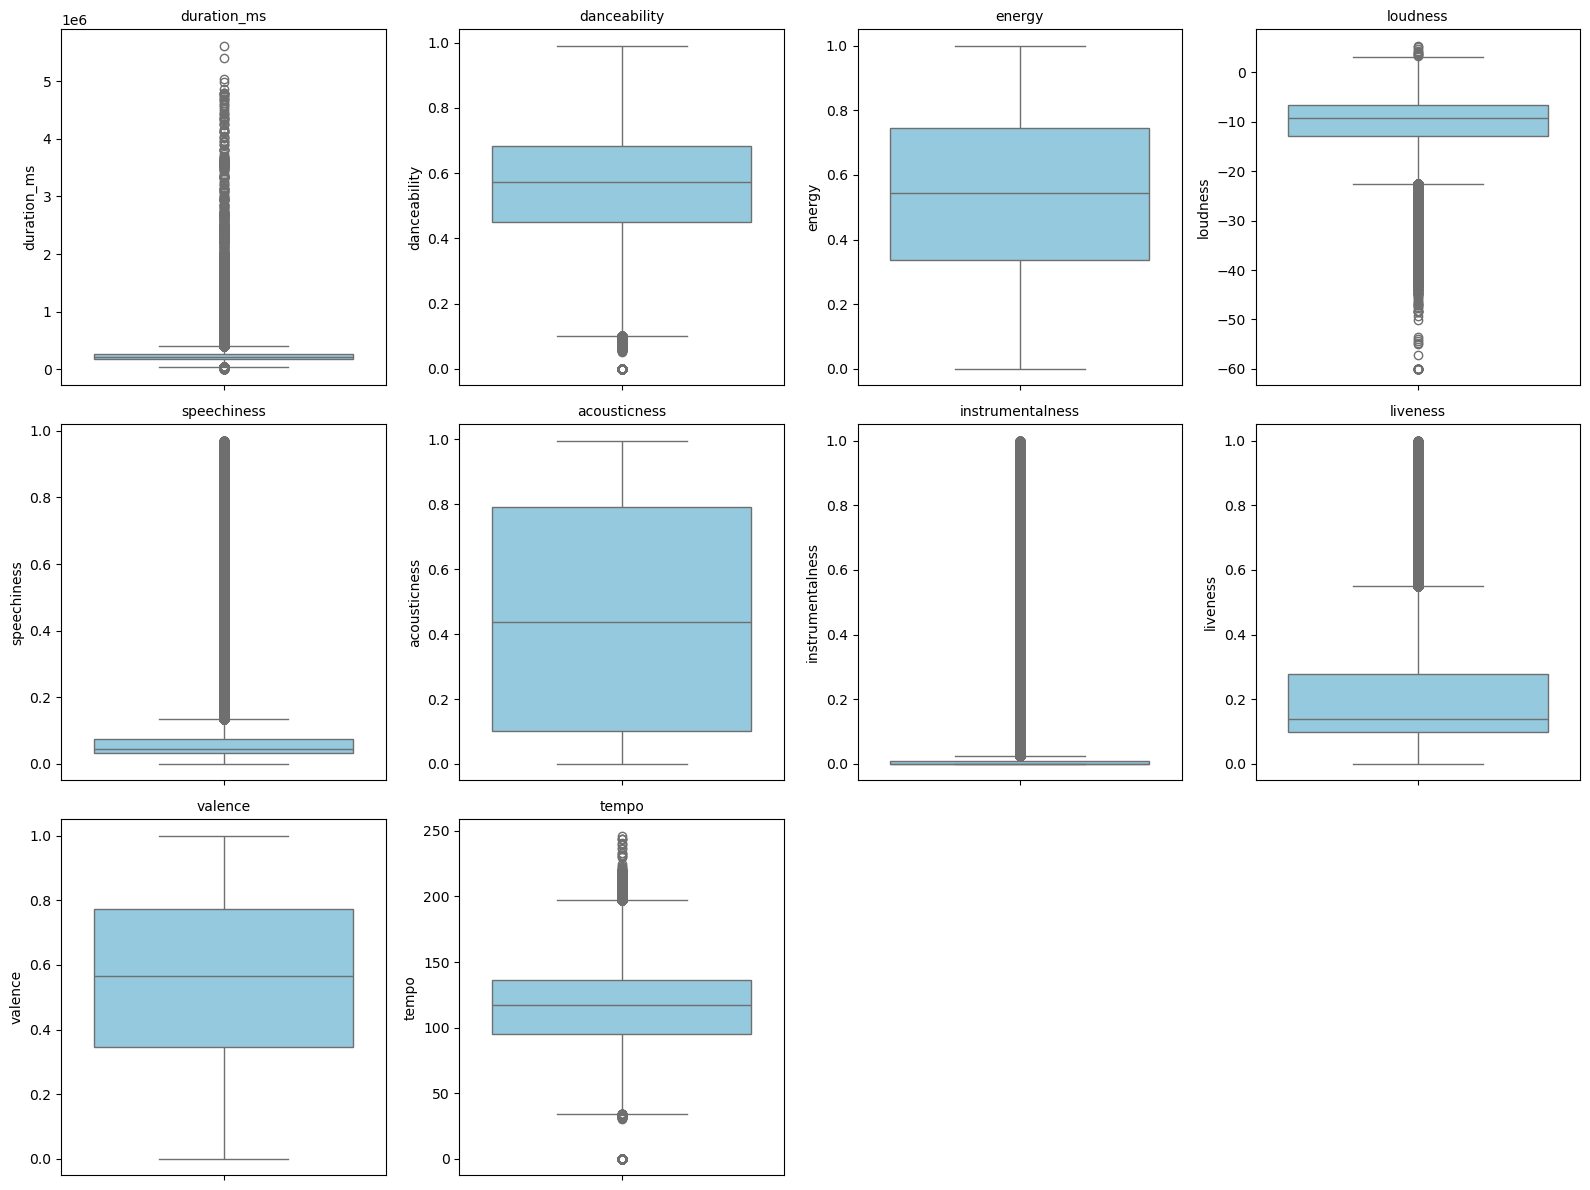

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

cols = 4  
rows = math.ceil(len(num_vars) / cols) 
plt.figure(figsize=(cols * 4, rows * 4))

for i, var in enumerate(num_vars):
    plt.subplot(rows, cols, i + 1) 
    sns.boxplot(y=tracks[var], color="skyblue")
    plt.title(f"{var}", fontsize=10)
    plt.xlabel("") 

plt.tight_layout()
plt.show()


The above-generated plots indicate that several of our numerical features contain outliers, and as such, the next step is to remove these outliers. Here, outliers are defined as any values that do not fall within the Q1 - 1.5 x IQR and Q3 + 1.5 × IQR of a certain variable.

In [16]:
def outlier_removal(num_var):
    """
    Function to remove outliers from a given column of a dataframe.

    Args:
        num_var (dataframe series): the column to be cleared of outliers.
        
    Prints: the number of observations dropped.
    """
    Q1 = tracks[num_var].quantile(0.25)
    Q3 = tracks[num_var].quantile(0.75)
    IQR = Q3 - Q1
    lower_thresh = Q1 - 1.5 * IQR
    upper_thresh = Q3 + 1.5 * IQR
    pre_drop_obs = tracks.shape[0]
    tracks.drop(tracks[(tracks[num_var] < lower_thresh) | \
        (tracks[num_var] > upper_thresh)].index, inplace=True)
    post_drop_obs = tracks.shape[0]
    print(f"For variable {num_var}, {pre_drop_obs - post_drop_obs} samples were "
          f"dropped for being outliers.")

for var in num_vars:
    outlier_removal(var)

For variable duration_ms, 26025 samples were dropped for being outliers.
For variable danceability, 1781 samples were dropped for being outliers.
For variable energy, 0 samples were dropped for being outliers.
For variable loudness, 13164 samples were dropped for being outliers.
For variable speechiness, 73524 samples were dropped for being outliers.
For variable acousticness, 0 samples were dropped for being outliers.
For variable instrumentalness, 97509 samples were dropped for being outliers.
For variable liveness, 21768 samples were dropped for being outliers.
For variable valence, 0 samples were dropped for being outliers.
For variable tempo, 3237 samples were dropped for being outliers.


Removing outliers leaves us with a total of 329,445 observations as well as the following breakdown of our target variable.

In [17]:
print(tracks.shape, "\n")
print(tracks.groupby('periods')['periods'].value_counts())

(329445, 14) 

periods
1920s-1940s      5076
1950s-1970s     46312
1980s-1990s    154212
2000s-2020s    123845
Name: count, dtype: int64


The next step comprises of scaling our numerical variables and generating dummies for our categorical features.

In [18]:
scaler = StandardScaler()
tracks[num_vars] = scaler.fit_transform(tracks[num_vars])

tracks[num_vars].describe()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,3.294450e+05,3.294450e+05,3.294450e+05,3.294450e+05,3.294450e+05,3.294450e+05,3.294450e+05,3.294450e+05,3.294450e+05,3.294450e+05
mean,-2.111926e-16,7.077713e-16,7.393466e-17,-1.401049e-16,-1.240584e-16,-2.016165e-16,6.021750e-17,-8.338139e-17,5.421300e-16,-1.152760e-15
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-3.102320e+00,-3.026584e+00,-2.408250e+00,-3.379639e+00,-1.128332e+00,-1.286305e+00,-3.398424e-01,-1.580682e+00,-2.223158e+00,-2.899838e+00
25%,-6.807843e-01,-6.711192e-01,-7.653810e-01,-6.538452e-01,-6.811603e-01,-9.844670e-01,-3.398424e-01,-7.210884e-01,-8.296305e-01,-7.749355e-01
50%,-6.164563e-02,5.874320e-02,1.362181e-02,1.434957e-01,-3.698937e-01,-1.128236e-01,-3.382457e-01,-3.886760e-01,3.685273e-02,-2.216305e-02
75%,6.292770e-01,7.222545e-01,8.098401e-01,7.672553e-01,3.052479e-01,9.189805e-01,-2.679393e-01,5.666441e-01,8.675637e-01,6.267775e-01
max,3.040747e+00,2.752599e+00,1.894419e+00,3.081759e+00,3.843165e+00,1.781384e+00,6.462757e+00,3.315627e+00,1.690325e+00,2.797254e+00


In [19]:
tracks = pd.get_dummies(tracks, columns=cat_vars, drop_first=True)

Having preprocessed our features, the next step is separate our features (Xs) and the target (y), followed by splitting the two into the training and testing sets. Since our target variable comprises of 4 classes or periods, we will split our training and testing sets by stratifying on y in order to ensure that the ratio between the training and testing set is maintained for each class.

In [20]:
X, y = tracks.drop(columns=["periods"]), tracks["periods"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [21]:
X_train.shape, X_test.shape

((230611, 23), (98834, 23))

In [22]:
X_train.head()

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,...,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11,mode_1
222905,0.699824,-0.843632,-1.342101,-0.983753,-0.843370,1.488783,-0.338760,-0.554395,-1.929428,-1.326804,...,False,False,False,False,False,False,True,False,False,True
559078,0.496892,-0.279648,1.300483,1.354444,1.028614,-1.286053,-0.339842,1.863150,0.450221,0.029190,...,False,False,False,False,True,False,False,False,False,True
414070,1.531206,-0.956429,-0.180053,0.630245,-0.650472,-0.088184,-0.339842,1.395238,-1.656367,0.675150,...,False,False,False,False,True,False,False,False,False,True
377400,0.657912,0.516566,1.304787,-0.945637,-0.172612,-1.050379,-0.339842,-0.863412,0.776146,1.085063,...,False,False,False,False,True,False,False,False,False,True
326328,-1.174340,-0.929889,-1.277543,-0.296896,-0.554023,1.584263,-0.338461,0.157221,-1.203252,-2.066638,...,False,False,False,False,False,False,True,False,False,True


**A note on models**

Let's turn to testing two models for our research question. We chose to deploy a multi-class logistic regression model and a RandomForest classifier. The first allows us to build a different model predicting whether or not samples belong to each separate period. This will help us answer our research question as it identifies the main features characterising music in each period separately, leading to a direct comparison of periods and their relevant musical features.

The RandomForestClassifier was chosen over a simple decision tree to improve our model robustness given that we are classifying multiple periods. The most prominent features used in the RandomForestClassifier will provide an account of the musical attributes that changed the most over the last 100 years, thus giving us an account of the general trends in muscial evolution.

## Fitting the multi-class logistic regression model

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Below is the first iteration of the model with the most basic parameters.

In [24]:
log_model = LogisticRegression(multi_class="multinomial", random_state=42)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

(print(f"Accuracy with baseline model:", np.round(accuracy_score(y_test, y_pred), 4)))

Accuracy with baseline model: 0.6586


Our baseline model provides us an accuracy of ~0.66%. That said, the next step is to tune our model with different solvers to identify the one delivering the best accuracy.

In [25]:
solvers = ["lbfgs", "newton-cg", "saga", "sag"]
for c in solvers:
    log_model = LogisticRegression(multi_class="multinomial", solver = c,
                                max_iter = 1000, random_state = 42)
    log_model.fit(X_train, y_train)
    y_pred = log_model.predict(X_test)
    (print(f"Accuracy with solver {c}:", np.round(accuracy_score(y_test, y_pred), 6)))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))    
    

Accuracy with solver lbfgs: 0.658579

Classification Report:
              precision    recall  f1-score   support

 1920s-1940s       0.49      0.08      0.14      1523
 1950s-1970s       0.54      0.46      0.50     13893
 1980s-1990s       0.67      0.71      0.69     46264
 2000s-2020s       0.68      0.70      0.69     37154

    accuracy                           0.66     98834
   macro avg       0.59      0.49      0.50     98834
weighted avg       0.65      0.66      0.65     98834

Accuracy with solver newton-cg: 0.658589

Classification Report:
              precision    recall  f1-score   support

 1920s-1940s       0.50      0.08      0.14      1523
 1950s-1970s       0.54      0.46      0.50     13893
 1980s-1990s       0.67      0.71      0.69     46264
 2000s-2020s       0.68      0.70      0.69     37154

    accuracy                           0.66     98834
   macro avg       0.60      0.49      0.50     98834
weighted avg       0.65      0.66      0.65     98834

Accu

From the above results, we can see that the results do not vary much across the different solvers. However, the solver newton-cg does provide the highest accuracy. Although the difference is marginal at best, we will proceed with this solver as continue fine-tuning our model. The next parameter to tune is the regularization strength or C; as per the official documentation provided by sklearn, the only penalty associated with the newton-cg solver is the l2 penalty. As such, we will incorporate the penalty "l2" with varying values of regularization strength in the next phase of developing our model. 

In [26]:
regularization_strengths = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
for c in regularization_strengths:
    log_model = LogisticRegression(multi_class="multinomial", solver = "newton-cg",
                                max_iter = 100, random_state = 42, penalty = "l2",
                                C = c)
    log_model.fit(X_train, y_train)
    y_pred = log_model.predict(X_test)
    (print(f"Accuracy with regularization strength {c}:", np.round(accuracy_score(y_test, y_pred), 6)))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))    

Accuracy with regularization strength 0.001: 0.657719

Classification Report:
              precision    recall  f1-score   support

 1920s-1940s       0.61      0.01      0.01      1523
 1950s-1970s       0.54      0.45      0.49     13893
 1980s-1990s       0.67      0.71      0.69     46264
 2000s-2020s       0.68      0.70      0.69     37154

    accuracy                           0.66     98834
   macro avg       0.62      0.47      0.47     98834
weighted avg       0.65      0.66      0.65     98834

Accuracy with regularization strength 0.01: 0.658205

Classification Report:
              precision    recall  f1-score   support

 1920s-1940s       0.50      0.04      0.08      1523
 1950s-1970s       0.53      0.46      0.50     13893
 1980s-1990s       0.67      0.71      0.69     46264
 2000s-2020s       0.68      0.70      0.69     37154

    accuracy                           0.66     98834
   macro avg       0.60      0.48      0.49     98834
weighted avg       0.65      0

Despite using different values for regularization strength, the impact on the accuracy remains marginal. Overall, our model is neither performing extremely well nor extremely poor. The fact that the accuracy of the model hovers around ~66% can be used to infer that our model is neither overfitting nor underfitting. Nonetheless, the classification report indicates that our model is struggling the 1920s-1940s class as the precision and recall for that specific subset is the lowest regardless of the value used for the regularization strength. That said, moving forward, we will use a regularization strength of 1.0 as it offers a balanced average across the precision, recall, and F-1 score. Additionally, one more parameter we could tune includes the weight assigned to each class; however, since we stratified the split on y while preparing the training and testing datasets, we do not need to tune this parameter. As such, below is the final model, we will proceed with.

In [27]:
log_model = LogisticRegression(multi_class="multinomial", solver = "newton-cg",
                            max_iter = 100, random_state = 42, penalty = "l2",
                            C = 1.0)
log_model

LogisticRegression(multi_class='multinomial', random_state=42,
                   solver='newton-cg')

In [28]:
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

In [29]:
(print(f"Accuracy of final model:", accuracy_score(y_test, y_pred)),2)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy of final model: 0.6585891494829714

Classification Report:
              precision    recall  f1-score   support

 1920s-1940s       0.50      0.08      0.14      1523
 1950s-1970s       0.54      0.46      0.50     13893
 1980s-1990s       0.67      0.71      0.69     46264
 2000s-2020s       0.68      0.70      0.69     37154

    accuracy                           0.66     98834
   macro avg       0.60      0.49      0.50     98834
weighted avg       0.65      0.66      0.65     98834


Confusion Matrix:
[[  120   997   193   213]
 [  104  6436  5912  1441]
 [   11  3332 32680 10241]
 [    6  1245 10048 25855]]


Given the above results, we can conclude that our model is able to correctly predict the musical period for ~66% of the tracks in our dataset. Additionally, from the confusion matrix as well as the classification report, we can see that our model struggles significantly with the 1920s-1940s class.This is, perhaps, caused by the fact that this class barely has over 5,000 samples, and as such, increasing the sample size might improve our model's performance. Additionally, our model performs the best when it comes to predicting the 1980s-1990s and the 2000s-2020s class with precisions (67% vs 68%) and recall (71% vs 70%). Given the unequal distribution of samples across our classes, we can use the weighted average to conclude that our model neither performs poorly nor very well. Overall, we observe the weighted average precision, recall, and f1-score values to be 65%, 66%, and 65% respectively, which once again signifies that on the average, our model does a moderately well job of classifying songs into musical periods.

Below are the intercepts we receive from our final model for each class.

In [30]:
log_model.intercept_

array([-5.14460554,  0.45764239,  2.60232463,  2.08463851])

In [31]:
coefficients = log_model.coef_
feature_names = X_train.columns 
coeff_df = pd.DataFrame(coefficients, columns=feature_names)

coeff_df

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,...,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11,mode_1
0,-0.101799,0.083682,-0.588331,0.197529,0.210549,2.460567,0.145355,0.180182,0.404164,-0.045477,...,0.245966,-0.268388,0.117709,-0.178691,0.064261,0.253135,-0.175463,0.044688,-0.432524,0.105759
1,-0.380313,-0.553005,-0.150530,-0.286027,0.012376,-0.186623,0.027286,0.028131,0.457055,-0.129136,...,0.049066,-0.066431,0.087333,-0.042667,-0.051025,0.134952,-0.057222,0.116771,-0.108299,0.022185
2,0.270491,-0.027695,0.641800,-0.754769,-0.181852,-1.077962,-0.053736,-0.086853,-0.122304,0.024802,...,-0.221885,0.185820,-0.132592,-0.048335,0.009574,-0.361177,0.153246,-0.140195,0.166309,-0.009040
3,0.211621,0.497018,0.097061,0.843267,-0.041073,-1.195983,-0.118904,-0.121460,-0.738914,0.149812,...,-0.073147,0.149000,-0.072449,0.269693,-0.022811,-0.026910,0.079439,-0.021265,0.374514,-0.118904


In [35]:
for i, row in enumerate(coeff_df.values):
    print(f"Top 3 features for class {log_model.classes_[i]}")
    sorted_features = pd.Series(row, index=feature_names).abs().sort_values(ascending=False)
    top_3 = sorted_features.head(3).index
    top_3_vars = pd.Series(row, index=feature_names).loc[top_3]
    
    print(top_3_vars)
    print("\n")


Top 3 features for class 1920s-1940s
acousticness    2.460567
energy         -0.588331
key_11         -0.432524
dtype: float64


Top 3 features for class 1950s-1970s
explicit_1     -1.662243
danceability   -0.553005
valence         0.457055
dtype: float64


Top 3 features for class 1980s-1990s
acousticness   -1.077962
loudness       -0.754769
energy          0.641800
dtype: float64


Top 3 features for class 2000s-2020s
explicit_1      1.420842
acousticness   -1.195983
loudness        0.843267
dtype: float64




From the above results of the multiclass logistic regression model, we can derive the following insights regarding how musical preferences have changes over time.

1. 1920s-1940s: This period is defined by high acousticness (2.46), lower energy (-0.59), and lower influence of a specific musical key (-0.43), i.e., B Major/G# Minor. Intuitively, it makes sense for acousticness to be the most important identifier of songs in this period, particularly because it marks an absence or minimal use of electronic or synthesized sounds. 
2. 1950s-1970s: The period of music between the 1950s-1970s is marked by a lower use of explicit or profane language in the song's lyrics with the coefficient being -1.66. Interesting, songs in this period also rank lower on the danceability scale but display a moderate level of positivity with the coefficients for danceability and valence being -0.55 and 0.46, respectively.
3. 1980s-1990s: The strongest marker of a song belonging to this period has to do with lower acousticness with the coefficient for this feature being -1.08, reflecting a rise in the use of electronic or synthesized music during this period. Additionally, the coefficient of -0.75 for loudness and 0.64 for energy dictate that songs in this period tend to be less loud but have a moderate to high level of energy.
4. 2000s-2020s: Not surprisingly, the strongest marker of a track belonging to the twenty-first century has to do with a higher use of explicit or profane language in the song's lyrics with the coefficient for this feature being 1.42. Again, intuitively, this makes sense with the rise of rap or hip-hop music in the 2000s. Additionally, we observe that a lack of acousticness also serves as an important signal for this period with the coefficient being -1.19; this, too, makes sense with the rise of EDM and techno music in the 2000s. Lastly, the coefficient of 0.84 for loudness indicates that as loudness increase, the odds of the song belonging to this period also increase.

## Fitting the RandomForestClassifier

**Establishing the Baseline Performance**

In [21]:
# packages for machine learning 
import sklearn
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import graphviz 
from sklearn.ensemble import RandomForestClassifier

# packages for testing
import random

# packages for plot and visualization
import matplotlib.pyplot as plt
from matplotlib import pylab
import graphviz 
pylab.rcParams["figure.figsize"] = (5.0, 4.0)
%matplotlib inline

In [ ]:
# First, create random forest object with defined random_state and appropriate criterion
rfc = RandomForestClassifier(n_estimators = 1000,
                             random_state=42, 
                             criterion='entropy')

# Fit the classifier on the training data
rfc = rfc.fit(X_train, y_train)

# NOTE: With n_estimators = 1000 and no other parameters, this took me 54 min (1hr) to run.
# I'll be sticking to the default n_estimators = 100 from now on to keep things efficient.

In [ ]:
# Check initial model performance: 0.71. Not too bad, but there's room for improvement
np.round(rfc.score(X_test,y_test),3)

0.71

In [ ]:
# To reduce the runtime, I will reduce n_estimators to the default (= 100). Will this affect
# model performance?
rfc = RandomForestClassifier(random_state=42, 
                             criterion='entropy')

# Fit the classifier on the training data
rfc = rfc.fit(X_train, y_train)


In [ ]:
# With n_estimators switched from 1000 to 100, we see a dramatic drop in training time (50' less)
# but only a minute drop in model score (-0.003). 
# It seems reducing n_estimators is a safe strategy to save on runtime.
np.round(rfc.score(X_test,y_test),3)

0.707

In [23]:
# What happens to the model when we reduce n_estimators all the way to 10?
rfc = RandomForestClassifier(n_estimators=10,
                             random_state=42, 
                             criterion='entropy')

# Fit the classifier on the training data
rfc = rfc.fit(X_train, y_train)

In [24]:
# BASELINE: 0.667. That is, we're correctly predicting 67.6% of target values in the testing data.
np.round(rfc.score(X_test,y_test),3)

# The model runtime is cut down by about 4mins 30sec (1/10th of n_est = 100), model performance
# drops by about 0.025. I will stick to n_estimators=10 for efficient model testing, and then
# switch back to 100 for the latest iteration of the model.

0.667

**Parameter Tuning**

In [26]:
# First off: Testing the possible node splitting criterions.
for crit in ["gini", "entropy", "log_loss"]:
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion=crit)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Criterion {crit}: ", np.round(rfc_tst.score(X_test,y_test),3))

# Conclusion: the differences between the different nodes plitting criteria are virutally nil.
# I will stick to entropy for now since this was the 'standard' approach discussed in class, 
# but the results show that when using a RandomForestClassifier for our RQ, the node splitting 
# criterion makes very little difference with regard to the model performance. 

Criterion gini:  0.666
Criterion entropy:  0.667
Criterion log_loss:  0.667


In [27]:
# Next: Let's check the depth the existing RFC (picking some random ones)
for i in range(0, 10, 3):
    print(rfc.estimators_[i].get_depth())

# All in the close range of 40-45. Let's see how the model changes if we pre-prune using 
# different criteria.

42
43
43
44


In [28]:
# There are various criteria for pre-pruning that specifically regulate the formation of leaves
# (rather than interfering with the node splitting process).
# Let's test each individually, before potentially combining them.

# First: stepwise increase of max_depth
for max_d in range(10, 51, 5):
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion="entropy",
                                max_depth=max_d)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Max. Depth = {max_d}: ", np.round(rfc_tst.score(X_test,y_test),3))

# We see that there seems to be a sweet spot for max_depth at around 15-20.
# By preventing the formation of trees that too closely mimic the training data,
# the max_depth pre-pruning criterion is thus succesful at preventing overfitting,
# though only mildly so in terms of absolute model performance.

Max. Depth = 10:  0.657
Max. Depth = 15:  0.673
Max. Depth = 20:  0.674
Max. Depth = 25:  0.668
Max. Depth = 30:  0.668
Max. Depth = 35:  0.666
Max. Depth = 40:  0.667
Max. Depth = 45:  0.667
Max. Depth = 50:  0.667


In [ ]:
# Second leaf-based criterion: min_samples_leaf
# This should hopefully allow for a more fruitful pre-pruning approach than 
# max_depth, as it directly targets specific end leaves.
for min_sl in range(20, 0, -2):
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion="entropy",
                                min_samples_leaf=min_sl)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Min. Leaf Sample = {min_sl}: ", np.round(rfc_tst.score(X_test,y_test),3))

# Min_samples_leaf improves model performance throughout the range tested here, though there is a
# sweet spot between 6-12.

# In general, there are more useful vals than in max_depth, presumably because it is more targeted 
# and thereby does not interefere with the splitting process when more would legitimately be needed.

# I'm wondering if the Ns chosen here may be in too small a range given the size of our data.
# After all, all values tested here improve model performance.
# Let's check larger min_samples_leaf for comparison.

Min. Leaf Sample = 20:  0.674
Min. Leaf Sample = 18:  0.674
Min. Leaf Sample = 16:  0.675
Min. Leaf Sample = 14:  0.675
Min. Leaf Sample = 12:  0.676
Min. Leaf Sample = 10:  0.676
Min. Leaf Sample = 8:  0.675
Min. Leaf Sample = 6:  0.676
Min. Leaf Sample = 4:  0.674
Min. Leaf Sample = 2:  0.672


In [ ]:
# Testing larger min_samples_values
for min_sl in range(200, 0, -20):
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion="entropy",
                                min_samples_leaf=min_sl)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Min. Leaf Sample = {min_sl}: ", np.round(rfc_tst.score(X_test,y_test),3))

# Choosing larger min_samples_leaf values did not do much to avoid overfitting; the largest values
# even reduced model performance compared to the baseline of 0.667. Setting the value for this
# parameter to below 20 (as done above) works best.

# In other words min_samples_leaf seems to be the most effective at avoiding overfitting when
# pruning just the lowest few levels of nodes with samples smaller than 6 (or 4). This parameter 
# ceases to be effective when it grows too high.

Min. Leaf Sample = 200:  0.658
Min. Leaf Sample = 180:  0.659
Min. Leaf Sample = 160:  0.661
Min. Leaf Sample = 140:  0.662
Min. Leaf Sample = 120:  0.663
Min. Leaf Sample = 100:  0.664
Min. Leaf Sample = 80:  0.667
Min. Leaf Sample = 60:  0.669
Min. Leaf Sample = 40:  0.67
Min. Leaf Sample = 20:  0.674


In [ ]:
# Third leaf-targetting parameter: max_leaf_nodes (by impurity)
# First, let's see how many leaves are on the trees
for i in range(0, 10, 3):
    print(rfc.estimators_[i].get_n_leaves())

# Trees in the RandomForest seem to have about 48k leaves.

48152
47813
48098
48530


In [ ]:
# Let's manipulate max_leaves in steps
# Curious to see how this differs from the min_leaf_sample approach, as both reduce leaf count.
for max_leaves in range(5000, 50000, 5000):
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion="entropy",
                                max_leaf_nodes=max_leaves)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Max. Leaf Nodes = {max_leaves}: ", np.round(rfc_tst.score(X_test,y_test),3))

# This approach does makes a positive difference for all values below 40k, with the benefit
# increasing as max_leaf_nodes approaches a lower value. Since we are at a pretty low resolution
# right now, let's focus on the seeminlgy best working range below 15k nodes.

Max. Leaf Nodes = 5000:  0.673
Max. Leaf Nodes = 10000:  0.674
Max. Leaf Nodes = 15000:  0.673
Max. Leaf Nodes = 20000:  0.673
Max. Leaf Nodes = 25000:  0.671
Max. Leaf Nodes = 30000:  0.671
Max. Leaf Nodes = 35000:  0.67
Max. Leaf Nodes = 40000:  0.668
Max. Leaf Nodes = 45000:  0.666


In [ ]:
# Focusing on a smaller range of max_leaf_nodes
for max_leaves in range(2, 15000, 1500):
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion="entropy",
                                max_leaf_nodes=max_leaves)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Max. Leaf Nodes = {max_leaves}: ", np.round(rfc_tst.score(X_test,y_test),3))

# 10k still seems to be the sweet spot, no better subcriterion found.

Max. Leaf Nodes = 2:  0.482
Max. Leaf Nodes = 1502:  0.668
Max. Leaf Nodes = 3002:  0.671
Max. Leaf Nodes = 4502:  0.673
Max. Leaf Nodes = 6002:  0.672
Max. Leaf Nodes = 7502:  0.673
Max. Leaf Nodes = 9002:  0.674
Max. Leaf Nodes = 10502:  0.674
Max. Leaf Nodes = 12002:  0.674
Max. Leaf Nodes = 13502:  0.673


In [ ]:
# The second general pre-pruning approach involves parameters that regulate the splitting process.
# Many of these parameters in some way 'mirror' parameters focusing on leaves,
# e.g., dictating min_sample_size to split on vs. dictating min_samples in a leaf.
# Let's compare these.

# First up: min_samples_split
for min_ss in range(20, 0, -2):
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion="entropy",
                                min_samples_split=min_ss)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Min. Split = {min_ss}: ", np.round(rfc_tst.score(X_test,y_test),3))

# The best scores are at the upper end of the min_split range tested here and are 
# comparable to using min_samples_leaf (best one at 0.676).

# I suspect the impact of this parameter will be a lot smaller if used alongside max_depth.
# Both reduce overfitting by limiting the creation of overly 'small' nodes.
# Let's test this intuition.

Min. Split = 20:  0.676
Min. Split = 18:  0.676
Min. Split = 16:  0.674
Min. Split = 14:  0.675
Min. Split = 12:  0.673
Min. Split = 10:  0.673
Min. Split = 8:  0.673
Min. Split = 6:  0.67
Min. Split = 4:  0.669
Min. Split = 2:  0.667


In [ ]:
# Testing different min_samples_split using max_depth = 20 (fixed)
for min_ss in range(20, 0, -2):
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion="entropy",
                                max_depth=20,
                                min_samples_split=min_ss)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Min. Sample Split = {min_ss}: ", np.round(rfc_tst.score(X_test,y_test),3))


# So when we have a fixed max_depth, we see that almost all scores are the same across different
# splitting thresholds. This is likely due to the fact that max_depth per se already limits the 
# tendency to split nodes into ever-smaller subnodes by stopping the splitting process earlier.

# Testing for the best combination of features using grid search will thus be crucial to obtain
# the best potential model.


Min. Sample Split = 20:  0.675
Min. Sample Split = 18:  0.676
Min. Sample Split = 16:  0.675
Min. Sample Split = 14:  0.677
Min. Sample Split = 12:  0.675
Min. Sample Split = 10:  0.674
Min. Sample Split = 8:  0.677
Min. Sample Split = 6:  0.675
Min. Sample Split = 4:  0.673
Min. Sample Split = 2:  0.674


In [35]:
# Second split-based parameter: min_impurity_decrease
for min_imp in range(5, 0, -1):
    min_imp = min_imp / 10
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion="entropy",
                                min_impurity_decrease=min_imp)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Min. Impurity Split = {min_imp}: ", np.round(rfc_tst.score(X_test,y_test),3))

# This parameter doesn't help improve the score; all values are equally worse.
# The percentage may simply be too large, so let's try smaller ones.


Min. Impurity Split = 0.5:  0.468
Min. Impurity Split = 0.4:  0.468
Min. Impurity Split = 0.3:  0.468
Min. Impurity Split = 0.2:  0.468
Min. Impurity Split = 0.1:  0.468


In [ ]:
# Smaller min_impunity_split range
for min_imp in range(5, 0, -1):
    min_imp = min_imp / 100 # Now at percentiles, not deciles.
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion="entropy",
                                min_impurity_decrease=min_imp)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Min. Impurity Split = {min_imp}: ", np.round(rfc_tst.score(X_test,y_test),3))

# Very small values improve model score somewhat, but not by much. Either way, the score remains 
# low with this parameter, so it won't be used in the final model. This is curious,
# as the spirit of this approach is similar to max_leaf_nodes; both work by making sure
# there is a certain level of entropy decrease by split/leaf. Max_leaf_nodes may work better
# because it is able to filter for specific nodes after splits, rather than preventing entire
# splits from happening.

Min. Impurity Split = 0.05:  0.468
Min. Impurity Split = 0.04:  0.468
Min. Impurity Split = 0.03:  0.468
Min. Impurity Split = 0.02:  0.468
Min. Impurity Split = 0.01:  0.592


In [37]:
# Third split-based parameter: max_features
# This one has no leaf-level equivalent, so I'm curious to see how it turns out

# First, let's just check with the categorical criterions.
for max_ft in ["sqrt", "log2", None]:
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion="entropy",
                                max_features=max_ft)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Max. Features Crit. = {max_ft}: ", np.round(rfc_tst.score(X_test,y_test),3))

# The other criteria (besides the default sqrt) do not improve model performance at all.
# I could check for individual integers, but ultimately the set of categories range from the lower
# end (sqrt/log2) to all (None). The magic may happen somewhere in between though, so let's check
# for those specifically.

Max. Features Crit. = sqrt:  0.667
Max. Features Crit. = log2:  0.667
Max. Features Crit. = None:  0.665


In [ ]:
# Checking for max_features using integers.
# We have 13 features. Sqrt and log2 both are in the 3-4 range. The in-between will be
# somewhere around 6-9, so let's test that.
for max_ft in range(6, 10):
    rfc_tst = RandomForestClassifier(n_estimators=10,
                                random_state=42, 
                                criterion="entropy",
                                max_features=max_ft)

    # Fit the classifier on the training data
    rfc_tst = rfc_tst.fit(X_train, y_train)

    print(f"Max. Features Int. = {max_ft}: ", np.round(rfc_tst.score(X_test,y_test),3))

# None of the 'in-between' values make a big difference, and in any case, they do not
# improve model performance by much. We can thus leave this parameter out of the final model.

Max. Features Int. = 6:  0.666
Max. Features Int. = 7:  0.668
Max. Features Int. = 8:  0.669
Max. Features Int. = 9:  0.669


**Recap** - Now that we have tested the most important pre-pruning model parameters, let's recap the main findings:
- The tuning of _most_ parameters did not make a big difference in terms of model performance (at least for the range of values tested). The largest improvements in model score did not surpass 0.1 points. Some of the largest changes were seen in parameter tunings that _decreased_ model performance, though these will evidently not be used in the final model.

- Though n_estimators could be one of the most effective ways to improve model performance, its utility is partly offset by the linear increase in runtime that its parameter tuning engenders.

- Two parameters effective in improving model performance were based on sample sizes: min_samples_leaf and min_samples_split. Still, the best-performing choices in these categories bumped the model score up only to 0.676 (delta to baseline: +0.09) or 0.677 (delta to baseline: +0.1). This approach seems particularly useful to avoid overfitting, but which of the two methods is really useful in combination with other tuned parameters will have to be seen in the grid search.

- The worst-performing parameters was min_impurity_split. Overly large values for this parameter decreased model performance to 0.468 (delta to baselin: -0.19). This is partly surprising, as defininig the maximum number of leaves, which works by selecting the top leaves by entropy decrease, instead positively affected the model performance. It seems that operating on the leaf rather than splitting dimension is more effective for this measure.

*A NOTE ON USING CCP*

The last parameter that could be tested is cost-complexity pruning (CCP). CCP is an instance of post-pruning (everything tested so far was pre-pruning) that recursively finds and removes the "weakest" leaf defined by an effective alpha (which is the parameter being set). Using the code provided in [this link](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html#sphx-glr-auto-examples-tree-plot-cost-complexity-pruning-py), we could identify the best alpha for a sample decision tree from the random forest and apply this to the entire random forest.

Though we tried to apply this procedure to identify the best CCP, the runtime went on for several hours just for a simple DecisionTree classifier, and would likely have taken even more time for a RandomForest classifier. We thus regret not being able to identify the ideal CCP for our model due to efficiency constraints and will not use this parameter in our final model.

**Combining features using grid search**

In [40]:
# Though we have examined potential tuning parameters and values on their own, their interactions
# may yield surprising results (as the combination of min_samples_split and max_depth showed).

# Additionally, the best performing tuning features were of a similar types (min_samples_leaf
# and min_samples_split work on samples size), so it's worth asking which of these features yields
# the best improvement in model performance.

# Grid search allows us to explore the best potential combination of these features/values.

from sklearn.model_selection import GridSearchCV

# Using the best-performing features and values from earlier.
rfc_gs = RandomForestClassifier(random_state=42, n_estimators=10, criterion="entropy")
parameters = {"min_samples_leaf": (6, 10, 12),
              "min_samples_split": (8, 14, 20),
              "max_depth": (15, 20),
              "max_leaf_nodes": (8000, 10000, 12000)}

# Running the GridSearch
grid_cv = GridSearchCV(estimator = rfc_gs, param_grid = parameters)
grid_cv.fit(X, y)


GridSearchCV(estimator=RandomForestClassifier(criterion='entropy',
                                              n_estimators=10,
                                              random_state=42),
             param_grid={'max_depth': (15, 20),
                         'max_leaf_nodes': (8000, 10000, 12000),
                         'min_samples_leaf': (6, 10, 12),
                         'min_samples_split': (8, 14, 20)})

In [42]:
# Let's check fit time and average scores
print(f"Mean fit times: {grid_cv.cv_results_['mean_fit_time']}\n")
print(f"Mean test scores: {grid_cv.cv_results_['mean_test_score']}")

Mean fit times: [ 7.94356928  7.84598718 10.06306815  9.46952615  7.65098729  8.16289968
  7.9362648   8.03517356  9.16135712  9.39971504  9.79125199  9.07394652
 11.08169131  9.95481753  9.51763048 10.05909147  8.9924418  10.00789957
  9.78167686  8.46726193  8.38905492  8.05997782  8.4407011   8.27879128
  8.26131744  8.76504741  9.05424681 11.20311289 10.45422802  9.9870193
  9.83019295 10.18118415 10.16572747 11.30730691 11.05702    10.85380511
 11.16274962 10.48934474 11.08619928 10.6945765  10.69658594 11.2069335
 11.68352585 10.66931076 10.46169949 12.34637938 11.50352268 10.88352814
 10.81097207 10.67018428 11.6990788  10.28479295 10.40959492 10.85575905]

Mean test scores: [0.6660778  0.66534019 0.66666363 0.6661294  0.6661294  0.6661294
 0.6657864  0.6657864  0.6657864  0.6660778  0.66534019 0.66666363
 0.6661294  0.6661294  0.6661294  0.6657864  0.6657864  0.6657864
 0.6660778  0.66534019 0.66666363 0.6661294  0.6661294  0.6661294
 0.6657864  0.6657864  0.6657864  0.66797189

In [ ]:
# Best values from the model grid search
print(f"Best estimator: {grid_cv.best_estimator_}\n")
print(f"Best parameters: {grid_cv.best_params_}\n")
print(f"Best score: {grid_cv.best_score_}")

Best estimator: RandomForestClassifier(criterion='entropy', max_depth=20, max_leaf_nodes=8000,
                       min_samples_leaf=12, min_samples_split=8,
                       n_estimators=10, random_state=42)

Best parameters: {'max_depth': 20, 'max_leaf_nodes': 8000, 'min_samples_leaf': 12, 'min_samples_split': 8}

Best score: 0.668815735555252


In [ ]:
# Showing the accuracy of our best model
rfc_best = RandomForestClassifier(criterion='entropy', max_depth=20, max_leaf_nodes=8000,
                       min_samples_leaf=12, min_samples_split=8,
                       n_estimators=10, random_state=42)

rfc_best.fit(X_train, y_train)
rfc_best.score(X_test, y_test)

0.6743833093874577

In [ ]:
# This is partly surprising: we were able to get better scores earlier, when tuning individual parameters and holding others constant.
# Let's just briefly check what happens when we set any of these to zero:
best_params = {'max_depth': 20, 'max_leaf_nodes': 8000, 'min_samples_leaf': 12, 'min_samples_split': 8} #grid_cv.best_params_

for param in best_params.keys():
    null_params = best_params
    if param == "min_samples_leaf":
        null_params[param] = 1
    elif param == "min_samples_split":
        null_params[param] = 2
    else:
        null_params[param] = None
    rfc_best_tst = RandomForestClassifier(criterion='entropy', max_depth=null_params["max_depth"], 
                                          max_leaf_nodes=null_params["max_leaf_nodes"], min_samples_leaf=null_params["min_samples_leaf"], 
                                          min_samples_split=null_params["min_samples_split"], n_estimators=10, random_state=42)

    rfc_best_tst.fit(X_train, y_train)

    print(f"Score after setting {param} to {null_params[param]}: {np.round(rfc_best_tst.score(X_test,y_test),3)}")

# As we can see, the best model score is in fact achieved when max_leaf_nodes is left at None. This shows the importance of including Zero
# or None values in the list of possible parameter values passed on to the grid search algorithm. We could technically re-run the grid search
# algorithm above by including the default values for each parameter, but for efficiency's sake we'll stick to the existing parameter values.

Score after setting max_depth to None: 0.675
Score after setting max_leaf_nodes to None: 0.676
Score after setting min_samples_leaf to 1: 0.673
Score after setting min_samples_split to 2: 0.667


**RECAP**:
- Even using a grid search algorithm, our best model score does not improve on the baseline by more than 1 percentage point. This simply be due to the pre-selection of features used to perform the grid search though. In our current approach, individual features and their values were chosen by setting all others to their default value. Consequently, our tuning process may have missed some interaction effects between parameters that would make other values more effective at tuning the model. 

- A surprising finding is that the best-performing model identified in the grid search shows a lower accuracy than some of the models seen during individual parameter tuning. As our in-depth analysis shows, this may be due to the lack of inclusion of the model's default values. Though we stuck to the model identified in the current grid search, we note that in our future applications of the grid search we may want to include the default values of the parameters in the permissible range. This would ensure that the conditions in which we tested parameters in the first place (i.e., where we kept all other parameters at their default values) can be replicated and potentially included as results during the grid search.

**Building and Evaluating the Final Model**

In [ ]:
# In the final step, we'll bump the model performance up a bit by increasing n_parameters to 100. We'll keep the other parameters found in the
# grid search.
RandomForestClassifier(criterion='entropy', max_depth=20, max_leaf_nodes=8000,
                       min_samples_leaf=12, min_samples_split=8,
                       n_estimators=100, random_state=42)

RandomForestClassifier(criterion='entropy', max_depth=20, max_leaf_nodes=8000,
                       min_samples_leaf=12, min_samples_split=8,
                       random_state=42)

In [ ]:
rfc_final = RandomForestClassifier(criterion='entropy', max_depth=20, max_leaf_nodes=8000,
                       min_samples_leaf=12, min_samples_split=8,
                       n_estimators=100, random_state=42)

rfc_final.fit(X_train, y_train)
print(f"Final Accuracy Score: {np.round(rfc_final.score(X_test,y_test),3)}")

Final Accuracy Score: 0.685


In [77]:
# So far, we have been relying heavily on the standard model score to evaluate model performance.
# The standard score measures the model's accuracy, though, which is an inaccurate metric for our
# data, given that the target counts are imbalanced.

# In the next and final step, let's explore the model in further depth using the classification report and confusion matrix.
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# Get predictions, print measures
y_pred = rfc_final.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, zero_division=np.nan)}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred, labels=tracks["periods"].unique())}")


Accuracy: 0.685492846591254

Classification Report:
              precision    recall  f1-score   support

 1920s-1940s       0.70      0.13      0.21      1523
 1950s-1970s       0.57      0.52      0.55     13893
 1980s-1990s       0.68      0.74      0.71     46264
 2000s-2020s       0.73      0.70      0.71     37154

    accuracy                           0.69     98834
   macro avg       0.67      0.52      0.55     98834
weighted avg       0.69      0.69      0.68     98834


Confusion Matrix:
[[  193  1134    28   168]
 [   72  7251   634  5936]
 [    4  1175 25933 10042]
 [    8  3087  8796 34373]]


In [ ]:
# Most important features
feature_importances = np.round(rfc_final.feature_importances_, 2)
df_wide = pd.DataFrame([feature_importances], columns=X.columns)

# Use melt to transform the wide DataFrame into a long DataFrame
df_long = df_wide.melt(var_name='Feature', value_name='Importance')

# Sort the features by importance (descending order)
df_long = df_long.sort_values(by='Importance', ascending=False)

print(df_long.head(10).reset_index(drop=True))

# Loudness is the most important feature, followed by acousticness and duration (in ms).

            Feature  Importance
0          loudness        0.23
1      acousticness        0.19
2       duration_ms        0.14
3            energy        0.11
4      danceability        0.07
5           valence        0.07
6       speechiness        0.05
7  instrumentalness        0.04
8          liveness        0.04
9             tempo        0.04


<Figure size 1200x600 with 0 Axes>

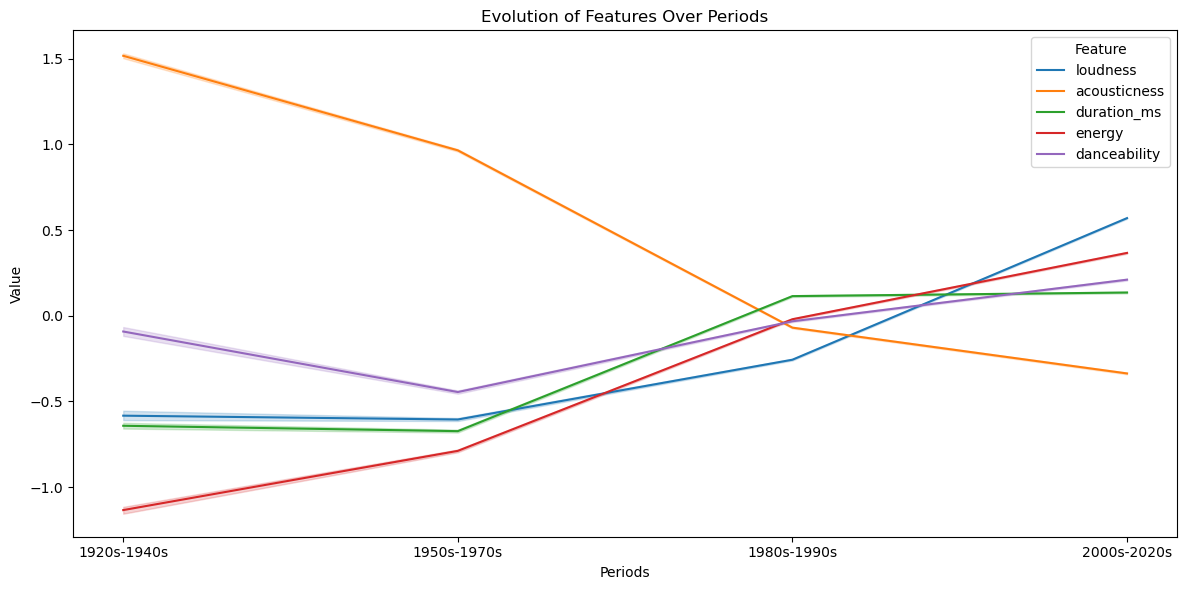

In [107]:
# Set the order of periods for plotting
period_order = ['1920s-1940s', '1950s-1970s', '1980s-1990s', '2000s-2020s']

# Melt the DataFrame to convert it from wide form to long form
melted_df = pd.melt(tracks, id_vars=['periods'], 
                    value_vars=['loudness', 'acousticness', 'duration_ms', 'energy', 'danceability'],
                    var_name='Feature', value_name='Value')

# Convert the 'periods' column to a categorical type with the specified order
melted_df['periods'] = pd.Categorical(melted_df['periods'], categories=period_order, ordered=True)

# Initialize matplotlib figure
plt.figure(figsize=(12, 6))

# Create line plot, customize it
sns.lineplot(x='periods', y='Value', hue='Feature', data=melted_df)
plt.title('Evolution of Features Over Periods')
plt.xlabel('Periods')
plt.ylabel('Value')
plt.legend(title='Feature')

# Show the plot
plt.tight_layout()
plt.show()

In [105]:
tracks.periods.unique()

array(['1920s-1940s', '1950s-1970s', '2000s-2020s', '1980s-1990s'],
      dtype=object)

**RECAP - Final RandomForestClassifier and Feature Interpretation (RQ)**
- Interpreting our model's top features for classifying songs, we see that loudness was the most effective feature for classification, followed by acousticness and duration (in ms). In other words, these are the features that are the most effectively used to classify songs into the different periods, and thus the ones that changed the most over time.

- Plotting the top 5 features over time, we see that one of the main driver of musical change has been the decrease in acousticness. This mirrors the finding from the logistic regression model, and reflects the historical drive away from classical music instrument toward electronically generated music.

- By contrast, loudness, energy, and danceability have all gone up more or less congruently. This trend is indicative of the rise of more 'popular' music that is fun, enjoyable, and has wide and instant appeal among the population (as opposed to more classical 'highbrow' music which may be a more acquired taste due to its higher musical complexity).

- The simultaneous rise of the bundle of 'popular' music markers may explain why the logistic regression model had issues distinguishing between specific periods, especially early on when these remained rather stable. It is also curious to see that loudness emerged as the most important feature in the RandomForestClassifier without appearing as the most important feature for any period in the Logistic Regression Model. This may be attributed to the fact that though it changed a lot and in the same direction over time, gathering importance as an aggregate feature, it did not change drastically between any specific periods and always increased alongside other features, thus remaining as a low predictor for period-specific classification.

In [ ]:
# For visualization, we used the code below to visualize one of the decision trees used in the random forest classifier.
# Unfortunately, graphviz worked on neither of our computers even after extensive attempts and debugging (incl. with TAs).

# We thus provide the code here though we ultimately ran it in Google Collab and extracted the graph as a png file that is found on 
# our GitHub Repos.
dot_data = tree.export_graphviz(rfc_final.estimators_[0], out_file=None, 
                                feature_names=X.columns, 
                                class_names=y.unique(),  
                                filled=True, rounded=True,  
                                special_characters=True)  
graph = graphviz.Source(dot_data)  
graph